Nome: Sofia Balerini de Vasconcellos

RA: 299904

Curso: Doutorado eng. elétrica



# Ex03 - Transformações de Intensidade (operações radiométricas)

Esta atividade tem 2 objetivos principais:
  - Entender o que são transformações radiométricas e como podem ser implementadas
  - Explorar duas aplicações para as transformações radiométricas: normalização e segmentação.

In [ ]:
# Importando as bibliotecas que serão utilizadas
import os

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image

In [ ]:
def download_image(url:str) -> str:
    filename = os.path.basename(url)

    if os.path.exists(filename):
        return filename

    response = requests.get(url)

    with open(filename, mode="wb") as file:
        file.write(response.content)

    return filename

## Parte 1 - Manipulando imagens

O código abaixo baixa e lê a imagem *flower.pgm* utilizando a biblioteca PIL/pillow, apresenta a imagem na tela e a transforma num array numpy.

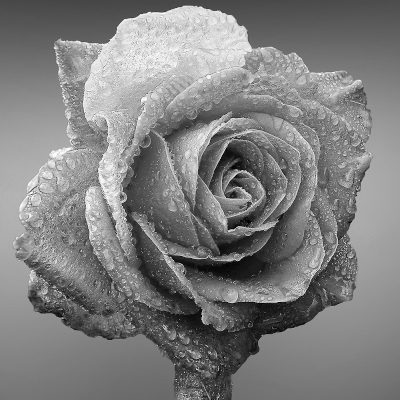

[[ 72  72  72 ...  78  77  77]
 [ 73  72  73 ...  78  78  78]
 [ 73  73  74 ...  78  78  79]
 ...
 [118 117 116 ... 107 107 106]
 [116 115 115 ... 106 106 106]
 [116 116 115 ... 106 106 106]]


In [ ]:
url = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/flower.pgm"
img_file = download_image(url)
img = Image.open(img_file)
display(img)

# Convertendo para um array do numpy
f=np.asarray(img)
print(f)

É bastante útil poder transformar Images em PIL em arrays numpy, e vice-versa. Isso permitirá que realizemos operações matriciais nas imagens e posteriormente possamos visualizar (e salvar em arquivos) as imagens processadas.

### Exercício 1.1

**a)** Classifique a imagem como monocromática (binária, grayscale) ou multibanda (tentando identificar o padrão multibanda adotado). Descubra: qual a profundidade da imagem? Qual o maior e o menor valor de intensidade de pixel da imagem (da imagem, não o teórico da profundidade)? Utilize para isso a biblioteca NumPy.

In [ ]:
#classificação da imagem

print("Dimensão:", f.shape)

if len(f.shape) == 2:
    print("Imagem monocromática (grayscale)")
elif len(f.shape) == 3:
    print("Imagem multibanda")


# profundidade (bits)

print("Tipo de dado:", f.dtype)


# valores mínimo e máximo

print("Valor mínimo:", np.min(f))
print("Valor máximo:", np.max(f))

Dimensão: (400, 400)
Imagem monocromática (grayscale)
Tipo de dado: uint8
Valor mínimo: 0
Valor máximo: 253


Tendo em vista que a imagem possui apenas um canal, ela é monocromática. Como os valores das intensidades dos pixels vai de 0 a 253, ela é uma imagem grayscale.

A profundidade da imagem é de 8 bits por pixel (uint8).

Maior valor de intensidade de pixel: 253
Menor valor de intensidade de pixel: 0


**b)** Leia a imagem *flower.pgm* utilizando a biblioteca matplotlib.image e mostre-a na tela. Exercite também o uso da barra de cores (colorbar).

Referência: [Tutorial Image Matplotlib](https://matplotlib.org/3.5.0/tutorials/introductory/images.html)

<details>
<summary>Dicas</summary>

- [matplotlib.pyplot.colobar](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.colorbar.html)

</details>

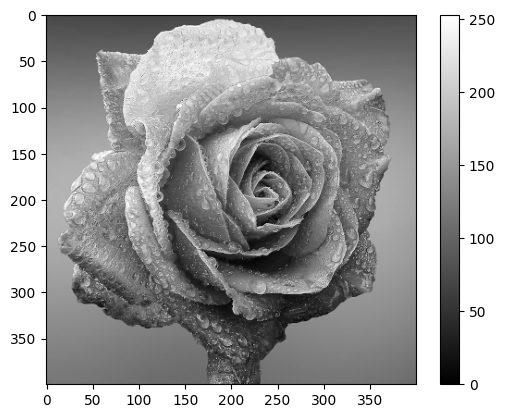

In [ ]:
# baixar imagem
url = "https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/flower.pgm"

response = requests.get(url)
with open("flower.pgm", "wb") as f:
    f.write(response.content)

# ler com matplotlib
img = mpimg.imread("flower.pgm")

# mostrar com colorbar
plt.imshow(img, cmap='gray')
plt.colorbar()


**c)** Usando atributos do tipo [`Image`](https://pillow.readthedocs.io/en/stable/reference/Image.html#image-attributes) da biblioteca `PIL`, tente responder as mesmas perguntas do item **a)**.

In [ ]:
url = "https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/flower.pgm"
img = Image.open(requests.get(url, stream=True).raw)

# informações com PIL
print("Modo:", img.mode)        # tipo de imagem
print("Tamanho:", img.size)     # (largura, altura)

# converter para numpy-
f = np.array(img)


# classificação
if img.mode == 'L':
    print("Imagem monocromática (grayscale)")
elif img.mode == '1':
    print("Imagem binária")
else:
    print("Imagem multibanda:", img.mode)


# profundidade
print("Profundidade:", f.dtype)

# valores min e max
print("Valor mínimo:", np.min(f))
print("Valor máximo:", np.max(f))

Modo: L
Tamanho: (400, 400)
Imagem monocromática (grayscale)
Profundidade: uint8
Valor mínimo: 0
Valor máximo: 253


O modo de uma imagem é uma string que define o tipo e a profundidade de um pixel na imagem. Cada pixel usa toda a gama de profundidade de bits.

Um pixel de 8 bits tem um intervalo de 0-255.

L: pixels de 8 bits, preto e branco

### Exercício 1.2

Imagine que a imagem está um pouco clara demais e decido escurecê-la um pouco. Minha primeira ideia seria subtrair um valor de cada pixel, uma vez que valores menores correspondem a cores mais escuras.

[[235 235 235 ... 241 240 240]
 [236 235 236 ... 241 241 241]
 [236 236 237 ... 241 241 242]
 ...
 [ 25  24  23 ...  14  14  13]
 [ 23  22  22 ...  13  13  13]
 [ 23  23  22 ...  13  13  13]]


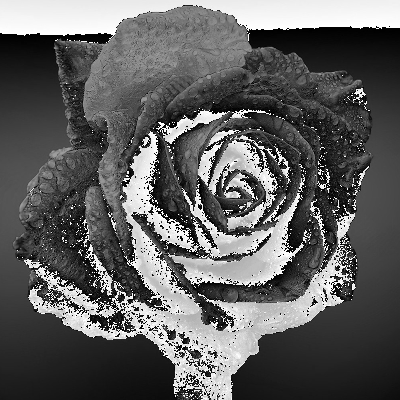

In [ ]:
# Vou escurecer a imagem, subtraindo um valor dos pixels do array f.
g=f-93
print(g)
# Agora vou transformar o array numa imagem PIL
g_img=Image.fromarray(g)
# E visualizar o resultado usando a função do PIL display
display(g_img)

**a)** Porque a imagem ficou mais clara ao invés de mais escura? Explique porque ao subtrair um determinado valor de intensidade da imagem original algumas regiões da imagem ficaram saturadas em branco.

*RESPOSTA:*

Como o tipo da imagem (dtype) é uint8, ela é capaz de representar apenas valores que vão de 0 a 255, não sendo capaz de representar valores negativos. Ao subtrair 93 de valores menores que 93, e obter valores negativos, a representação retorna os valores abaixo da saturação (255).

---
A principal mensagem é que podemos realizar operações quaisquer com os valores de pixel mas, no fim do dia, caso queiramos visualizar essas imagens, temos que pensar como esses valores serão mapeados para uma codificação que faça sentido no seu sistema computacional de apresentação.


**b)** Tente refazer esta mesma operação de "escurecimento" da imagem através de subtração, sem que esse efeito de saturação aconteça. Comente os métodos utilizados.

<details>
<summary>Dicas</summary>

- [numpy.clip](https://numpy.org/doc/stable/reference/generated/numpy.clip.html)

</details>

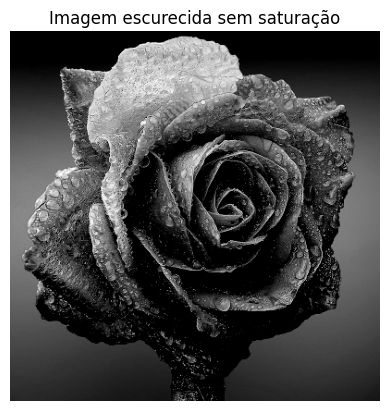

In [ ]:
# carregar imagem
url = "https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/flower.pgm"
img = Image.open(requests.get(url, stream=True).raw)
f = np.array(img)

# converter para inteiro maior (evita overflow)
f_int = f.astype(np.int16)

# subtrair valor
g = f_int - 93

# limitar valores entre 0 e 255
g = np.clip(g, 0, 255)

# voltar para uint8
g = g.astype(np.uint8)

# mostrar resultado
plt.imshow(g, cmap='gray')
plt.title("Imagem escurecida sem saturação")
plt.axis('off')
plt.show()

## Parte 2 - Transformação de Intensidade

Tranformações de intensidade ou transformações rediométricas alteram o valor do pixel aplicando-se uma função ou tabela de mapeamento. Para entender como isso é implementado na prática, estudem atentamente o tutorial sobre ["Transformações de intensidade"](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/tutorial_ti_2.ipynb).

[[ 72  72  72 ...  78  77  77]
 [ 73  72  73 ...  78  78  78]
 [ 73  73  74 ...  78  78  79]
 ...
 [118 117 116 ... 107 107 106]
 [116 115 115 ... 106 106 106]
 [116 116 115 ... 106 106 106]]


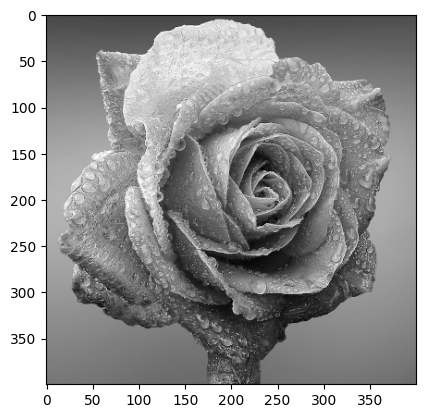

In [ ]:
print(f)
plt.imshow(f,cmap='gray')

Vamos exercitar a aplicação de um mapeamento f = T[f] a partir de uma função de transformação T. No nosso caso, a função T será o negativo da imagem.

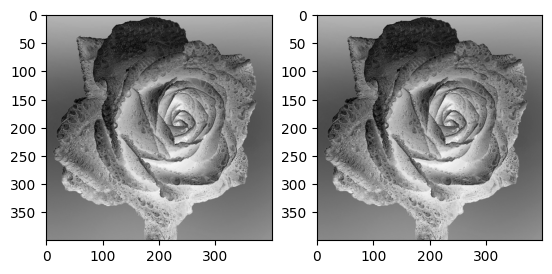

In [ ]:
T = np.arange(256).astype('uint8')        # função identidade
T1 = 255 - T                              # criando a função negação a partir da identidade
#print(T1)
T2 = np.arange(255,-1,-1).astype('uint8') # criando diretamente a função negação
#print(T2)

plt.subplot(1,2,1)
f1 = T1[f]
plt.imshow(f1,cmap='gray')
plt.subplot(1,2,2)
f2 = T2[f]
plt.imshow(f2,cmap='gray')


### Exercício 2.1

Utilize transformações radiométricas para transformar a imagem e identificar o número da placa do carro apresentado na imagem abaixo. Explique seu raciocínio para chegar na solução.

float32


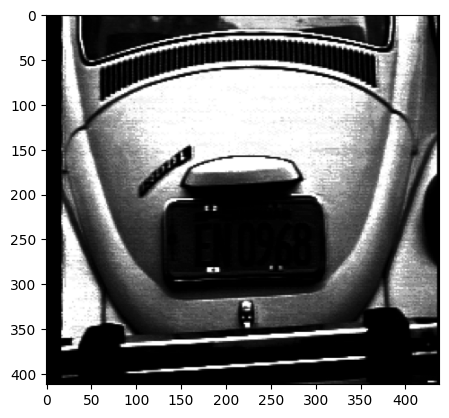

In [ ]:
fusca_url = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/fusca.png"
f = mpimg.imread(download_image(fusca_url))
plt.imshow(f,cmap='gray')
print(f.dtype)

dtype original: float32


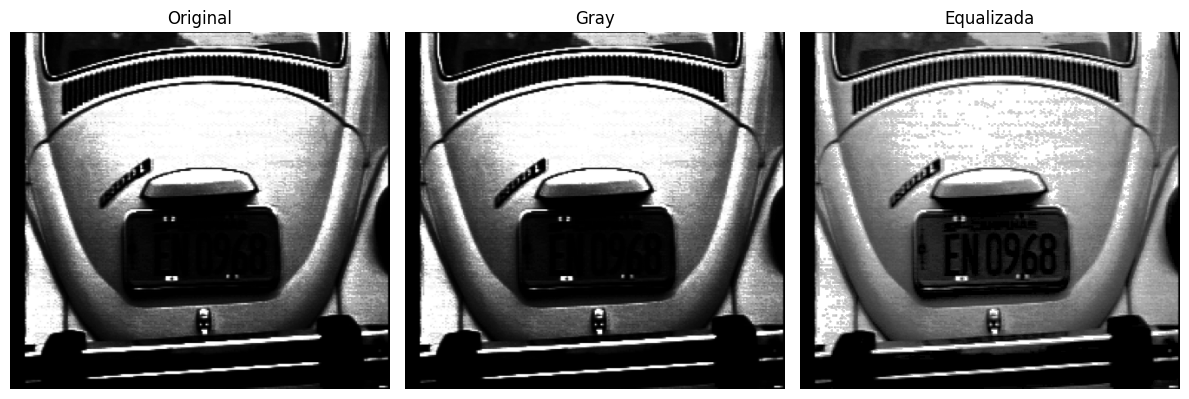

In [ ]:
# leitura da imagem
f = mpimg.imread(download_image(fusca_url))
print("dtype original:", f.dtype)

# garantir escala de cinza
if len(f.shape) == 3:
    f_gray = cv2.cvtColor((f*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
else:
    f_gray = (f*255).astype(np.uint8)

# normalização (0–255)
f_norm = cv2.normalize(f_gray, None, 0, 255, cv2.NORM_MINMAX)

# equalização de histograma
f_eq = cv2.equalizeHist(f_norm)



# VISUALIZAÇÃO DOS RESULTADOS
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.title("Original")
plt.imshow(f, cmap='gray')
plt.axis('off')

plt.subplot(2,3,2)
plt.title("Gray")
plt.imshow(f_gray, cmap='gray')
plt.axis('off')

plt.subplot(2,3,3)
plt.title("Equalizada")
plt.imshow(f_eq, cmap='gray')
plt.axis('off')


plt.tight_layout()
plt.show()

Foram aplicadas transformações radiométricas com o objetivo de melhorar o contraste da imagem e facilitar a identificação da placa do veículo. Inicialmente, a imagem foi convertida para escala de cinza e normalizada para o intervalo de intensidades padrão. Em seguida, utilizou-se a equalização de histograma para redistribuir os níveis de cinza, aumentando o contraste global. Como resultado, observou-se uma melhora significativa na visibilidade dos caracteres da placa, embora com aumento de ruído em algumas regiões. Ainda assim, a técnica mostrou-se eficaz para realce de detalhes relevantes.


### Exercício 2.2

Uma das possíveis aplicações das transformações radiométricas é a segmentação de imagens, onde destacamos um objeto de interesse dos demais objetos (ou do fundo).

**a)** A imagem abaixo mostra duas bolachas. Escolha um valor de limiar (threshold) para separar a bolacha do fundo da imagem. Crie uma função de transformação T e aplique esta transformação para obter os objetos de interesse (bolachas) pintados de branco e o fundo em preto. Comente os métodos utilizados.

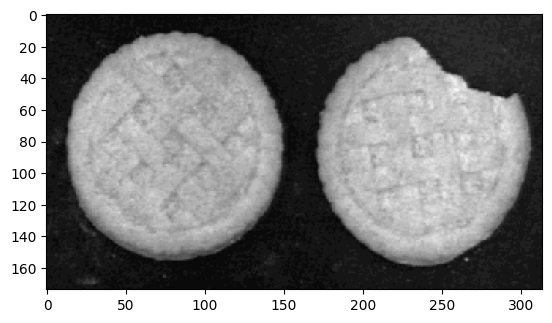

In [ ]:
cookies_url = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/cookies.pgm"
plt.subplot(111)
f = mpimg.imread(download_image(cookies_url))
plt.imshow(f,cmap='gray')

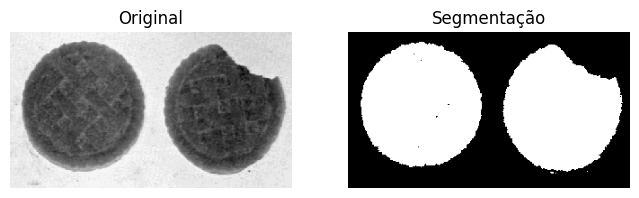

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import requests
import os

def download_image(url):
    filename = os.path.basename(url)
    if not os.path.exists(filename):
        r = requests.get(url)
        with open(filename, "wb") as f:
            f.write(r.content)
    return filename

# carregar imagem
url = "https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/cookies.pgm"
f = mpimg.imread(download_image(url))

# converter se necessário
f = (f * 255).astype(np.uint8)

# threshold correto (invertido)
threshold = 150
g = (f < threshold) * 255
g = g.astype(np.uint8)

# plot
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(f, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(g, cmap='gray')
plt.title("Segmentação")
plt.axis('off')

plt.show()

A segmentação foi realizada por meio de uma transformação radiométrica baseada em limiarização, utilizando um valor de threshold igual a 150. Como as bolachas apresentam intensidades menores que o fundo, foi aplicada uma limiarização binária invertida, destacando os objetos de interesse em branco e o fundo em preto.

### Exercício 2.3

In [ ]:
orquidea_url = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/orquideafeec-calua.jpg"
download_image(orquidea_url)

'orquideafeec-calua.jpg'

Leia e apresente a imagem `orquideafeec-calua.jpg`. Execute processamentos de intensidade nas diferentes bandas da imagem (R, G, B). Comente os métodos utilizados e resultados obtidos. É possível segmentar a flor da orquídea usando uma única banda de cor?

Dica: exemplos disponíveis em [Applying point transforms e Processing individual bands](https://pillow.readthedocs.io/en/stable/handbook/tutorial.html#image-enhancement).

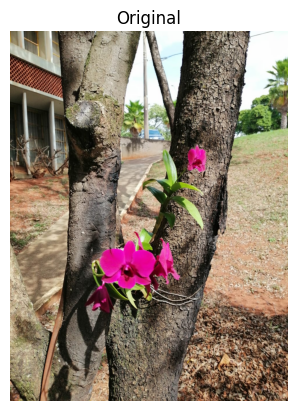

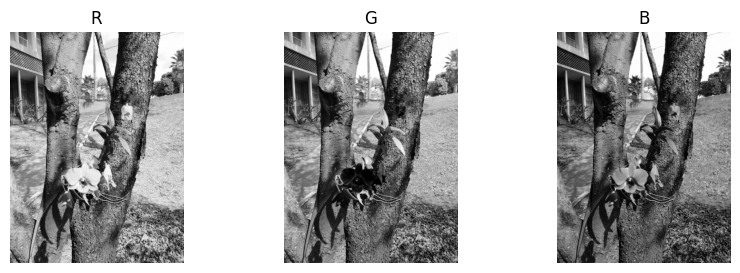

In [ ]:
# carregar imagem
url = "https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/orquideafeec-calua.jpg"
img = mpimg.imread(download_image(url))

# mostrar original
plt.imshow(img)
plt.title("Original")
plt.axis('off')
plt.show()

# -------------------------
# separar bandas
# -------------------------
R = img[:,:,0]
G = img[:,:,1]
B = img[:,:,2]

# -------------------------
# mostrar bandas
# -------------------------
plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.imshow(R, cmap='gray')
plt.title("R")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(G, cmap='gray')
plt.title("G")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(B, cmap='gray')
plt.title("B")
plt.axis('off')

plt.show()


A imagem foi decomposta em suas bandas R, G e B, e cada uma foi analisada individualmente por meio de sua representação em escala de cinza. Observou-se que a flor apresenta alta intensidade nas bandas R(principalmente) e B, devido à sua coloração magenta, enquanto na banda G ela aparece mais escura. Embora as bandas R e B permitam destacar a flor em relação ao fundo, a utilização de apenas uma banda não é suficiente para uma segmentação precisa, pois outras regiões da imagem também apresentam intensidades semelhantes. Assim, métodos que combinem múltiplas bandas seriam mais adequados para isolar corretamente a flor.

## Parte 3 - Contando moedas em uma imagem (opicional para EA979)

In [ ]:
url_base = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/{value}.jpg"
values = [75, 80, 95]

filenames = []

for value in values:
    url = url_base.format(value=value)
    filename = download_image(url)
    filenames.append(filename)

Observe atentamente e tente entender os códigos abaixo, que aplicam diversas funções e conceitos para obter o valor total de um conjunto de moedas (de 5, 10 ou 25 centavos) presentes em uma imagem. De maneira geral, foram utilizadas funções de limiarização, obtenção de componentes conexos e morfologia matemática.

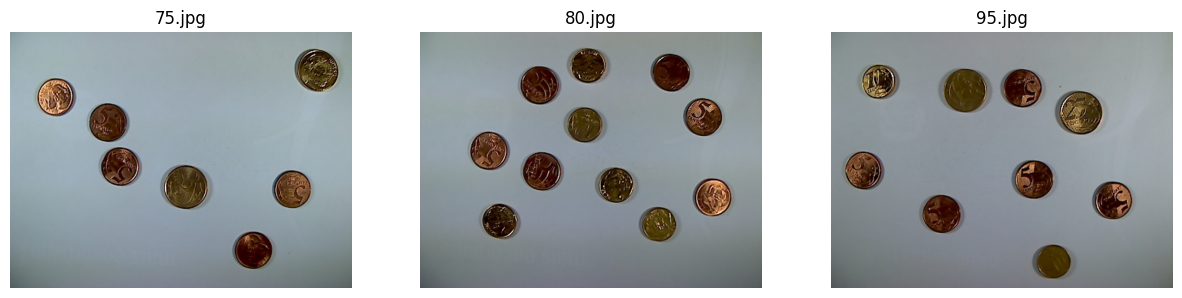

In [ ]:
fig, axs = plt.subplots(1,3,figsize=(15, 6))

for i, file in enumerate(filenames):
  plt.subplot(1,3,1+i)
  plt.axis('off')
  plt.title(file)
  img = mpimg.imread(file)
  plt.imshow(img)

In [ ]:
import cv2

def seg_and_postprocessing(img, k_cl, k_op):
    binr = cv2.threshold(255 - img, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1]

    kernel_cl = np.ones((k_cl, k_cl), np.uint8)
    kernel_op = np.ones((k_op, k_op), np.uint8)

    close = cv2.morphologyEx(binr, cv2.MORPH_CLOSE, kernel_cl, iterations=1)
    open = cv2.morphologyEx(close, cv2.MORPH_OPEN, kernel_op, iterations=1)

    plt.figure(figsize=(12,6))
    plt.subplot(1,3,1)
    plt.imshow(binr, cmap='gray')
    plt.axis('off')
    plt.subplot(1,3,2)
    plt.imshow(close, cmap='gray')
    plt.axis('off')
    plt.subplot(1,3,3)
    plt.imshow(open, cmap='gray')
    plt.axis('off')
    plt.show()

    return open

In [ ]:
def calc_npixels_label(img, n_labels):
    list_npixels = []
    for v in range(n_labels-1):
        npixels = (img[img == v+1]//(v+1)).sum()
        list_npixels.append(npixels)
    return list_npixels

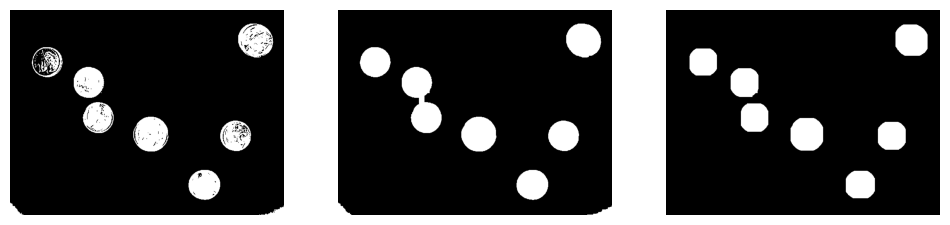

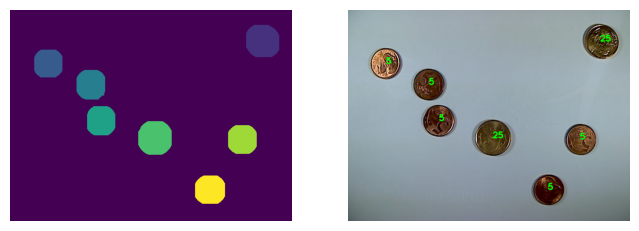

Imagem 75.jpg
Número de moedas 7
[np.int64(4805), np.int64(3638), np.int64(3867), np.int64(3786), np.int64(5016), np.int64(3767), np.int64(3861)]
Valor total: 75



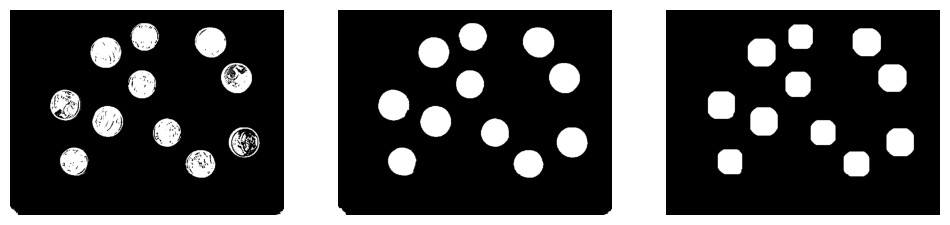

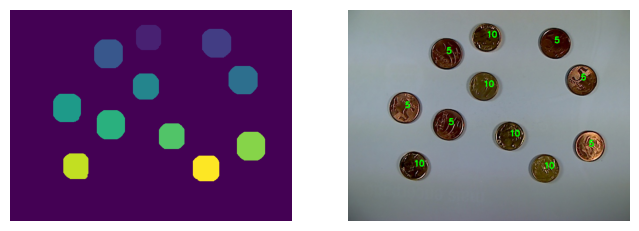

Imagem 80.jpg
Número de moedas 11
[np.int64(2978), np.int64(3793), np.int64(3775), np.int64(3736), np.int64(3132), np.int64(3678), np.int64(3778), np.int64(3064), np.int64(3728), np.int64(3049), np.int64(3183)]
Valor total: 80



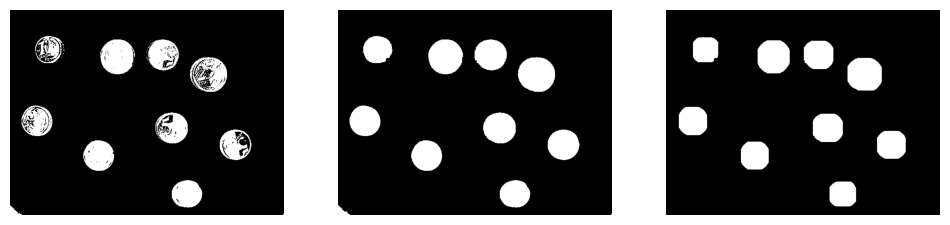

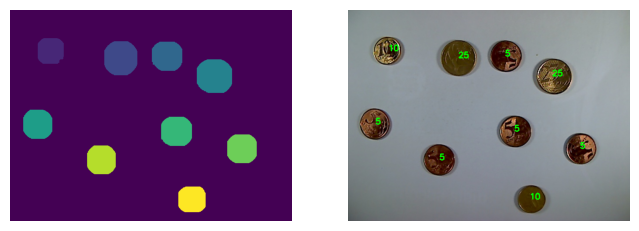

Imagem 95.jpg
Número de moedas 9
[np.int64(3114), np.int64(4997), np.int64(4017), np.int64(5335), np.int64(3845), np.int64(4113), np.int64(3897), np.int64(3766), np.int64(3285)]
Valor total: 95



In [ ]:
for i, file in enumerate(filenames):
  img = mpimg.imread(file).astype('uint8')
  img_gray = np.uint8(0.3*img[:,:,0]+0.59*img[:,:,1]+0.11*img[:,:,2])

  seg_img = seg_and_postprocessing(img_gray, 15, 31)
  output = cv2.connectedComponentsWithStats(seg_img, 4)

  plt.figure(figsize=(8,4))
  plt.subplot(1,2,1)
  plt.imshow(output[1])
  plt.axis('off')

  list_npixels = calc_npixels_label(output[1], output[0])

  soma = 0
  for n, p in enumerate(list_npixels):
    x = int(output[3][n+1][0])
    y = int(output[3][n+1][1])

    if p < 3500:
      soma += 10
      cv2.putText(img, '10', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    elif p > 4600:
      soma += 25
      cv2.putText(img, '25', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    else:
      soma += 5
      cv2.putText(img, '5', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.axis('off')
  plt.show()

  print('Imagem', file)
  print('Número de moedas', len(list_npixels))
  print(list_npixels)
  print('Valor total:', soma)
  print()

### Exercício 3.1

Utilizando como base os códigos apresentados anteriormente, crie um novo Notebook que seja uma demonstração (demo) de como obter o valor total de um conjunto de moedas em uma imagem. O Notebook deve conter uma breve descrição do problema e deve explicar passo a passo as etapas e códigos utilizados para chegar ao resultado final. Tente descrever e exemplificar cada etapa, indicando qual o seu objetivo, explicando os processamentos aplicados, as funções utilizadas e os parâmetros escolhidos. Ao final do Notebook, apresente links para referências úteis no aprofundamento dos tópicos abordados. Você também pode linkar referências interessantes ao longo do Notebook, à medida que apresenta as etapas e os conceitos relacionados.

Não se esqueça de enviar o Notebook da demo juntamente com a entrega deste Notebook!